# Peak Segmentation Visualization

목표:

- raw 시계열을 기준으로 joint angle 그래프를 그림
- stance phase(contact==1) 구간을 반투명 초록색으로 표시
- peak_records.csv에 기록된 IQR 통과 피크는 파란색 점으로 표시
- peak_records.csv에 기록된 IQR 탈락 피크는 노란색 점으로 표시
- 함수화해서 특정 ID/속도 또는 여러 ID 반복 실행 가능하게 구성

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import pyarrow.dataset as ds
import pyarrow.compute as pc
import matplotlib.pyplot as plt
from IPython.display import display

cwd = Path.cwd()
project_root = cwd if (cwd / "AGENTS.md").exists() else cwd.parent
print("CWD:", cwd)
print("PROJECT_ROOT:", project_root)

PATH_RAW = project_root / "data/processed/raw_merged.parquet"
PATH_ID = project_root / "data/ID.csv"
PATH_ANALYSIS = project_root / "data/processed/analysis_data.csv"
PATH_PEAKS = project_root / "data/processed/peak_records.csv"

assert PATH_RAW.exists(), f"raw parquet 없음: {PATH_RAW}"
assert PATH_ID.exists(), f"ID.csv 없음: {PATH_ID}"
assert PATH_ANALYSIS.exists(), f"analysis_data.csv 없음: {PATH_ANALYSIS}"
assert PATH_PEAKS.exists(), f"peak_records.csv 없음: {PATH_PEAKS}"

print("입력 파일 확인 완료")

CWD: /Users/ryutt/Desktop/mini_ryutt/Walking/notebooks
PROJECT_ROOT: /Users/ryutt/Desktop/mini_ryutt/Walking
입력 파일 확인 완료


In [2]:
SUBJECT_ID_ALIASES = {
    "ACLR38": "ACLR36",
}

JOINT_COLS = {
    "hip_flexion": ("jointAngle_42", "jointAngle_54"),
    "hip_adduction": ("jointAngle_43", "jointAngle_55"),
    "hip_int_rotation": ("jointAngle_44", "jointAngle_56"),
    "knee_flexion": ("jointAngle_45", "jointAngle_57"),
    "knee_adduction": ("jointAngle_46", "jointAngle_58"),
    "knee_int_rotation": ("jointAngle_47", "jointAngle_59"),
    "ankle_dorsiflexion": ("jointAngle_48", "jointAngle_60"),
    "ankle_adduction": ("jointAngle_49", "jointAngle_61"),
    "ankle_int_rotation": ("jointAngle_50", "jointAngle_62"),
}

FOOT_CONTACT_COLS = {
    "Right": "footContacts_2",
    "Left": "footContacts_0",
}

print("상수 정의 완료")

상수 정의 완료


In [3]:
def _canonical_subject_id(subject_id: str) -> str:
    return SUBJECT_ID_ALIASES.get(subject_id, subject_id)


def _subject_candidates_for_raw(subject_id: str) -> list:
    canonical = _canonical_subject_id(subject_id)
    candidates = [canonical]
    alias_sources = [src for src, canon in SUBJECT_ID_ALIASES.items() if canon == canonical]
    for src in alias_sources:
        if src not in candidates:
            candidates.append(src)
    if subject_id not in candidates:
        candidates.append(subject_id)
    return candidates


def load_subject_speed_timeseries(subject_id: str, speed: str) -> pd.DataFrame:
    speed_norm = str(speed).strip().lower()
    subject_candidates = _subject_candidates_for_raw(subject_id)

    raw_cols = list({col for pair in JOINT_COLS.values() for col in pair})
    cols = ["subject_id", "speed", "time_ms"] + raw_cols + list(FOOT_CONTACT_COLS.values())
    cols = list(dict.fromkeys(cols))

    dataset = ds.dataset(PATH_RAW.as_posix(), format="parquet")
    filter_expr = pc.field("subject_id").isin(subject_candidates) & (pc.field("speed") == speed_norm)
    table = dataset.to_table(columns=cols, filter=filter_expr)
    df = table.to_pandas()

    if df.empty:
        raise ValueError(f"원시 데이터 없음: subject_id={subject_id}, speed={speed_norm}")

    df["subject_id"] = df["subject_id"].replace(SUBJECT_ID_ALIASES)
    df["time_ms"] = pd.to_numeric(df["time_ms"], errors="coerce")
    return df.sort_values("time_ms").reset_index(drop=True)


def load_id_table() -> pd.DataFrame:
    return pd.read_csv(PATH_ID)


def load_peak_records_table() -> pd.DataFrame:
    df = pd.read_csv(PATH_PEAKS)
    df["subject_id"] = df["subject_id"].replace(SUBJECT_ID_ALIASES)
    df["speed"] = df["speed"].astype(str).str.lower().str.strip()
    if "iqr_pass" in df.columns:
        df["iqr_pass"] = df["iqr_pass"].astype(bool)
    return df


def infer_injured_leg(subject_id: str, id_df: pd.DataFrame) -> str:
    canonical = _canonical_subject_id(subject_id)
    rows = id_df[id_df["ID"].isin([canonical, subject_id])]
    if not rows.empty:
        leg = rows["Injured leg"].iloc[0]
        if isinstance(leg, str) and leg in {"Right", "Left"}:
            return leg
    return "Right"


def get_stance_segments(contact_signal: np.ndarray) -> list:
    contact_binary = np.asarray(contact_signal, dtype=int)
    segments = []
    seg_start = None

    for idx, val in enumerate(contact_binary):
        if val == 1 and seg_start is None:
            seg_start = idx
        elif val != 1 and seg_start is not None:
            segments.append((seg_start, idx))
            seg_start = None

    if seg_start is not None:
        segments.append((seg_start, len(contact_binary)))

    return segments


def plot_peak_segmentation(
    subject_id: str,
    speed: str = "normal",
    leg_mode: str = "injured",
    features: list | None = None,
    max_cols: int = 3,
):
    id_df = load_id_table()
    peaks_df = load_peak_records_table()

    canonical_id = _canonical_subject_id(subject_id)
    speed_norm = str(speed).strip().lower()

    raw_df = load_subject_speed_timeseries(canonical_id, speed_norm)

    injured_leg = infer_injured_leg(canonical_id, id_df)
    leg_mode_lower = str(leg_mode).lower()
    if leg_mode_lower == "injured":
        target_leg = injured_leg
    elif leg_mode_lower == "contralateral":
        target_leg = "Left" if injured_leg == "Right" else "Right"
    elif leg_mode_lower in {"right", "left"}:
        target_leg = leg_mode_lower.capitalize()
    else:
        raise ValueError("leg_mode는 injured/contralateral/right/left 중 하나여야 합니다.")

    side_kind = "injured" if target_leg == injured_leg else "contralateral"

    target_peaks = peaks_df[
        (peaks_df["subject_id"] == canonical_id)
        & (peaks_df["speed"] == speed_norm)
        & (peaks_df["side"] == side_kind)
    ].copy()

    selected_features = list(JOINT_COLS.keys()) if features is None else features
    n_features = len(selected_features)
    ncols = min(max_cols, n_features)
    nrows = int(np.ceil(n_features / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(5.6 * ncols, 3.6 * nrows), squeeze=False)
    flat_axes = axes.flatten()

    summary_rows = []

    for i, feat in enumerate(selected_features):
        ax = flat_axes[i]

        right_col, left_col = JOINT_COLS[feat]
        signal_col = right_col if target_leg == "Right" else left_col
        contact_col = FOOT_CONTACT_COLS[target_leg]

        signal_raw = pd.to_numeric(raw_df[signal_col], errors="coerce").to_numpy(dtype=float)
        contact_signal = pd.to_numeric(raw_df[contact_col], errors="coerce").fillna(0).to_numpy(dtype=int)

        x = pd.to_numeric(raw_df["time_ms"], errors="coerce").to_numpy(dtype=float)
        if np.isnan(x).all():
            x = np.arange(len(raw_df), dtype=float)
            x_label = "frame_index"
        else:
            x_label = "time_ms"

        stance_segments = get_stance_segments(contact_signal)

        feat_peaks = target_peaks[target_peaks["feature"] == feat].copy()
        valid_peaks = feat_peaks[feat_peaks["iqr_pass"] == True]
        rejected_peaks = feat_peaks[feat_peaks["iqr_pass"] == False]

        ax.plot(x, signal_raw, color="black", linewidth=1.2, label=f"{feat} ({target_leg})")

        for seg_start, seg_end in stance_segments:
            if seg_end <= seg_start:
                continue
            ax.axvspan(x[seg_start], x[seg_end - 1], color="green", alpha=0.14)

        if not valid_peaks.empty:
            xp = pd.to_numeric(valid_peaks["time_ms"], errors="coerce").to_numpy(dtype=float)
            yp = pd.to_numeric(valid_peaks["peak_value"], errors="coerce").to_numpy(dtype=float)
            if np.isnan(xp).all():
                xp = pd.to_numeric(valid_peaks["peak_index"], errors="coerce").to_numpy(dtype=float)
            ax.scatter(xp, yp, color="#1f77b4", s=26, zorder=5, label="valid peaks")

        if not rejected_peaks.empty:
            xr = pd.to_numeric(rejected_peaks["time_ms"], errors="coerce").to_numpy(dtype=float)
            yr = pd.to_numeric(rejected_peaks["peak_value"], errors="coerce").to_numpy(dtype=float)
            if np.isnan(xr).all():
                xr = pd.to_numeric(rejected_peaks["peak_index"], errors="coerce").to_numpy(dtype=float)
            ax.scatter(
                xr,
                yr,
                color="#f2c500",
                edgecolor="#8a6d00",
                linewidth=0.5,
                s=30,
                zorder=5,
                label="IQR rejected",
            )

        ax.set_title(f"{feat} | valid={len(valid_peaks)} | reject={len(rejected_peaks)}", fontsize=10)
        ax.set_xlabel(x_label)
        ax.set_ylabel("joint angle")
        ax.grid(alpha=0.25, linestyle="--")

        handles, labels = ax.get_legend_handles_labels()
        unique = dict(zip(labels, handles))
        if unique:
            ax.legend(unique.values(), unique.keys(), fontsize=8, loc="best")

        summary_rows.append(
            {
                "subject_id": canonical_id,
                "speed": speed_norm,
                "feature": feat,
                "side": side_kind,
                "leg": target_leg,
                "signal_col": signal_col,
                "contact_col": contact_col,
                "valid_peaks": len(valid_peaks),
                "rejected_peaks": len(rejected_peaks),
                "total_peaks": len(feat_peaks),
            }
        )

    for j in range(n_features, len(flat_axes)):
        flat_axes[j].axis("off")

    fig.suptitle(f"subject={canonical_id} | speed={speed_norm} | side={side_kind}", fontsize=14)
    fig.tight_layout()

    summary_df = pd.DataFrame(summary_rows)
    return raw_df, target_peaks, summary_df, fig


def plot_peak_segmentation_for_ids(subject_ids: list, speed: str = "normal", **kwargs):
    outputs = {}
    for sid in subject_ids:
        raw_df, peak_df, summary_df, _ = plot_peak_segmentation(subject_id=sid, speed=speed, **kwargs)
        print(f"\n===== subject_id={sid}, speed={speed} =====")
        display(summary_df)
        plt.show()
        outputs[sid] = {
            "raw": raw_df,
            "peaks": peak_df,
            "summary": summary_df,
        }
    return outputs

raw rows: 4023
peak rows (filtered by subject/speed/side): 315


,subject_id,speed,feature,side,leg,signal_col,contact_col,valid_peaks,rejected_peaks,total_peaks
0,ACLD12,normal,hip_flexion,injured,Right,jointAngle_42,footContacts_2,33,2,35
1,ACLD12,normal,hip_adduction,injured,Right,jointAngle_43,footContacts_2,32,3,35
2,ACLD12,normal,hip_int_rotation,injured,Right,jointAngle_44,footContacts_2,31,4,35
3,ACLD12,normal,knee_flexion,injured,Right,jointAngle_45,footContacts_2,35,0,35
4,ACLD12,normal,knee_adduction,injured,Right,jointAngle_46,footContacts_2,35,0,35
5,ACLD12,normal,knee_int_rotation,injured,Right,jointAngle_47,footContacts_2,33,2,35
6,ACLD12,normal,ankle_dorsiflexion,injured,Right,jointAngle_48,footContacts_2,30,5,35
7,ACLD12,normal,ankle_adduction,injured,Right,jointAngle_49,footContacts_2,32,3,35
8,ACLD12,normal,ankle_int_rotation,injured,Right,jointAngle_50,footContacts_2,34,1,35


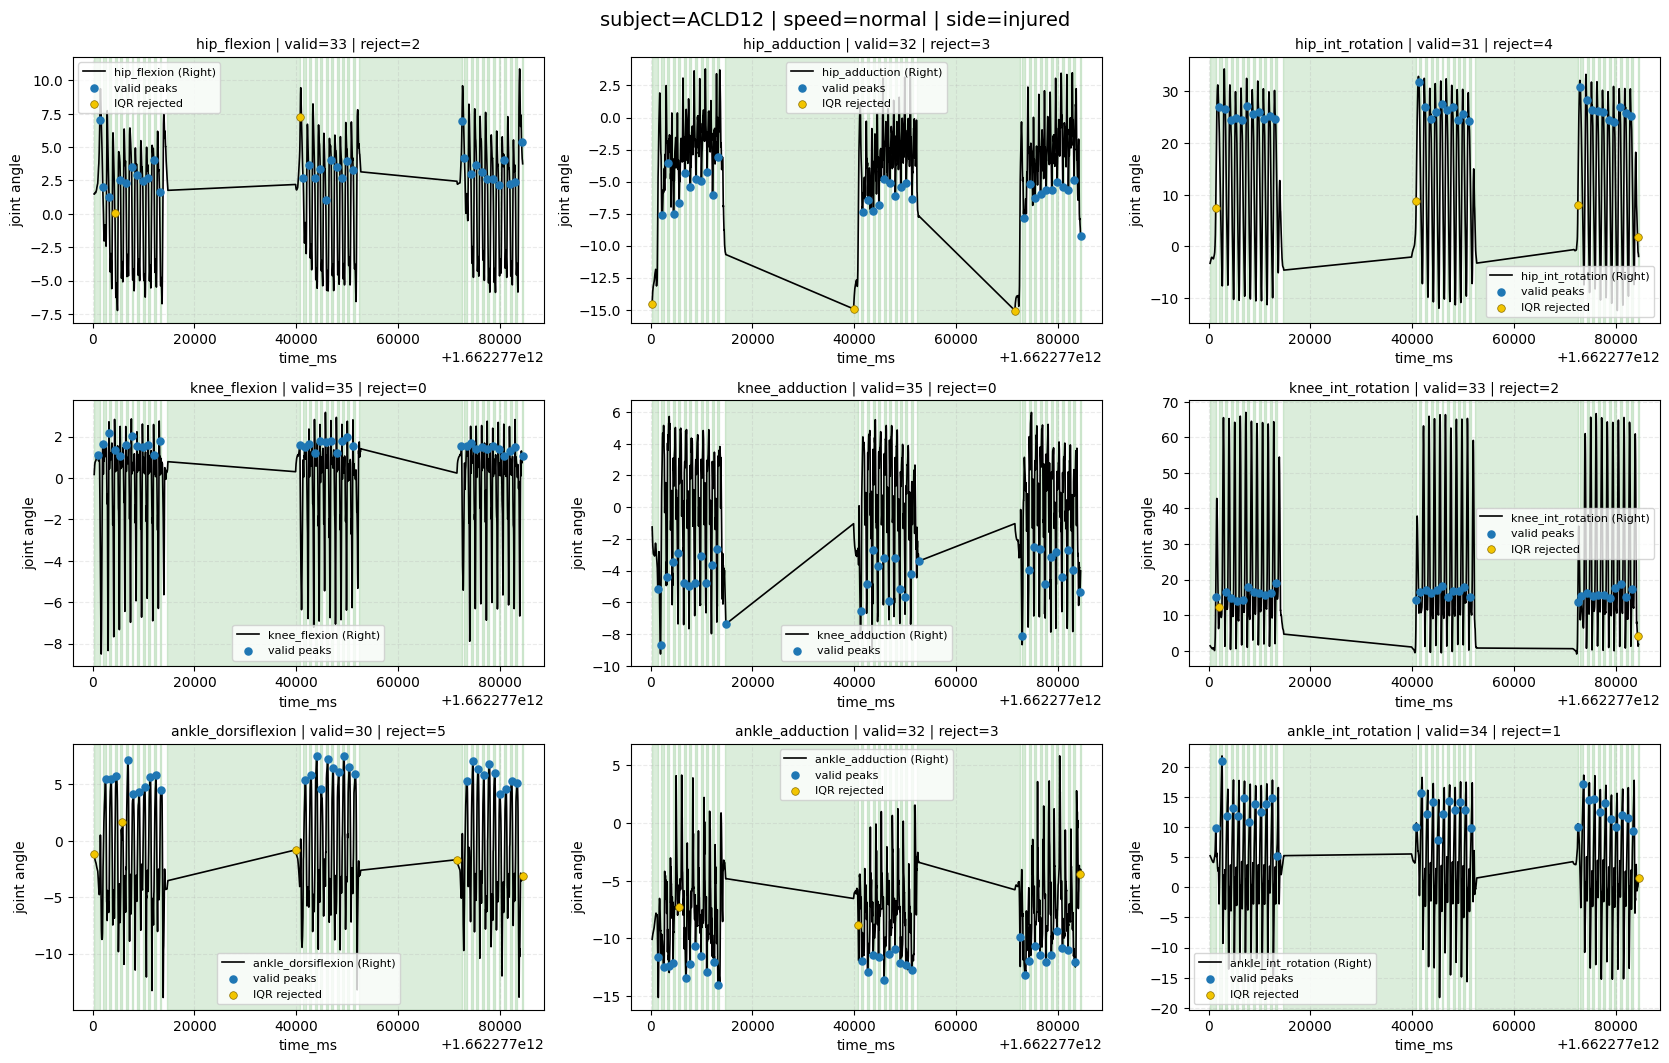

In [4]:
# 예시 실행: 특정 ID + 특정 속도

target_id = "ACLD12"
target_speed = "normal"

raw_df, peak_df, summary_df, _ = plot_peak_segmentation(
    subject_id=target_id,
    speed=target_speed,
    leg_mode="injured",
)

print("raw rows:", len(raw_df))
print("peak rows (filtered by subject/speed/side):", len(peak_df))
display(summary_df)

# 여러 ID를 반복 실행하고 싶으면 아래 예시를 사용
# outputs = plot_peak_segmentation_for_ids(["ACLD12", "ACLD14"], speed="normal", leg_mode="injured")